# Titanic: Who Survived and Why?

**Goal:** explore the passenger data from the sinking of the RMS Titanic, find out which factors were linked to survival, and build a simple machine-learning model that predicts whether a passenger survived.

**Data:** [Kaggle – Titanic: Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data) (`train.csv`, 891 passengers).

**Contents**
1. Load and inspect the data
2. Data cleaning
3. Exploratory data analysis (EDA)
4. Feature engineering
5. Modelling
6. Conclusions

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/train.csv")
print(f"Rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()

Rows: 891, columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


| Column | Meaning |
|---|---|
| `Survived` | 0 = No, 1 = Yes (**target**) |
| `Pclass` | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| `SibSp` | # siblings / spouses aboard |
| `Parch` | # parents / children aboard |
| `Embarked` | Port: C = Cherbourg, Q = Queenstown, S = Southampton |

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing": missing, "percent": missing_pct}).query("missing > 0")

,missing,percent
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


**Observations**
- `Cabin` is missing for ~77% of passengers – too sparse to use directly.
- `Age` is missing for ~20% – worth filling in.
- `Embarked` is missing for only 2 passengers.

## 2. Data cleaning

In [5]:
data = df.copy()

# Title from the name (Mr, Mrs, Miss, Master, ...) – useful for age and survival
data["Title"] = data["Name"].str.extract(r",\s*([^\.]+)\.")
data["Title"] = data["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
rare = data["Title"].value_counts()[lambda s: s < 10].index
data["Title"] = data["Title"].replace(rare, "Rare")

# Fill missing Age with the median age of passengers who share the same title
data["Age"] = data.groupby("Title")["Age"].transform(lambda s: s.fillna(s.median()))

# Fill the 2 missing Embarked values with the most common port
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Keep only whether a cabin was recorded
data["HasCabin"] = data["Cabin"].notna().astype(int)

data[["Age", "Embarked", "Title", "HasCabin"]].isna().sum()

Age         0
Embarked    0
Title       0
HasCabin    0
dtype: int64

## 3. Exploratory data analysis

Overall survival rate: 38.4%


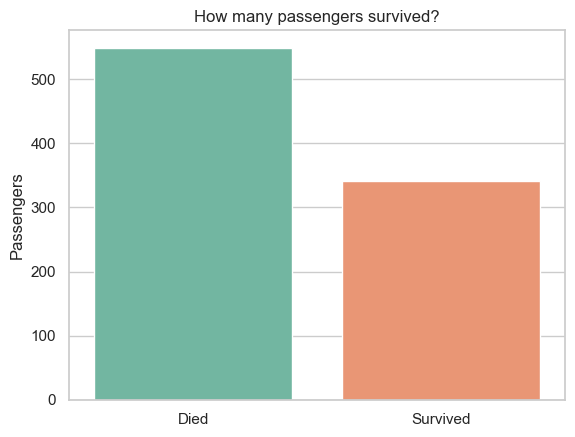

In [6]:
survival_rate = data["Survived"].mean()
print(f"Overall survival rate: {survival_rate:.1%}")

ax = sns.countplot(data=data, x="Survived")
ax.set_xticks([0, 1], ["Died", "Survived"])
ax.set(title="How many passengers survived?", xlabel="", ylabel="Passengers")
plt.show()

### Survival by sex and ticket class

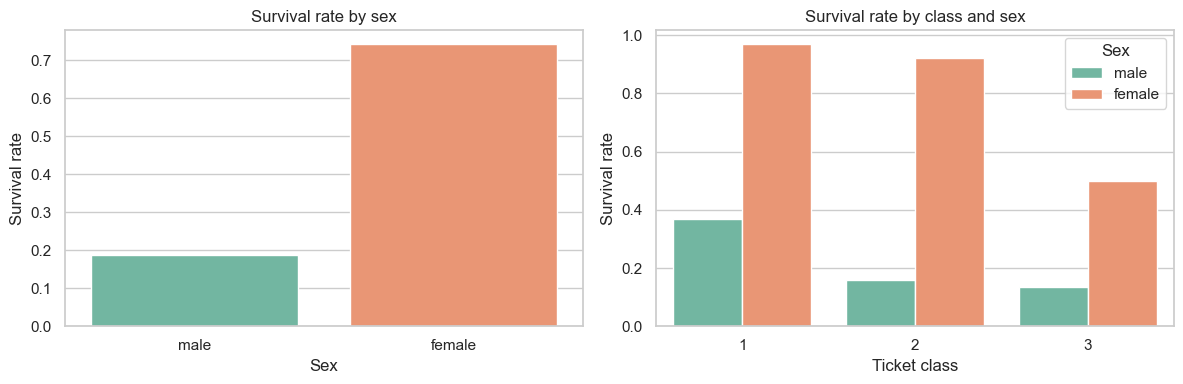

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=data, x="Sex", y="Survived", ax=axes[0], errorbar=None)
axes[0].set(title="Survival rate by sex", ylabel="Survival rate")

sns.barplot(data=data, x="Pclass", y="Survived", hue="Sex", ax=axes[1], errorbar=None)
axes[1].set(title="Survival rate by class and sex", xlabel="Ticket class", ylabel="Survival rate")

plt.tight_layout()
plt.savefig("../images/survival_by_sex_class.png", dpi=120)
plt.show()

In [8]:
pd.crosstab([data["Pclass"], data["Sex"]], data["Survived"], normalize="index").round(2)

Survived          0     1
Pclass Sex               
1      female  0.03  0.97
       male    0.63  0.37
2      female  0.08  0.92
       male    0.84  0.16
3      female  0.50  0.50
       male    0.86  0.14

**"Women and children first"** is clearly visible: about 74% of women survived versus 19% of men.
Class mattered too – almost all women in 1st and 2nd class survived, while only half of 3rd‑class women did.

### Survival by age

/Users/olgakoleda/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


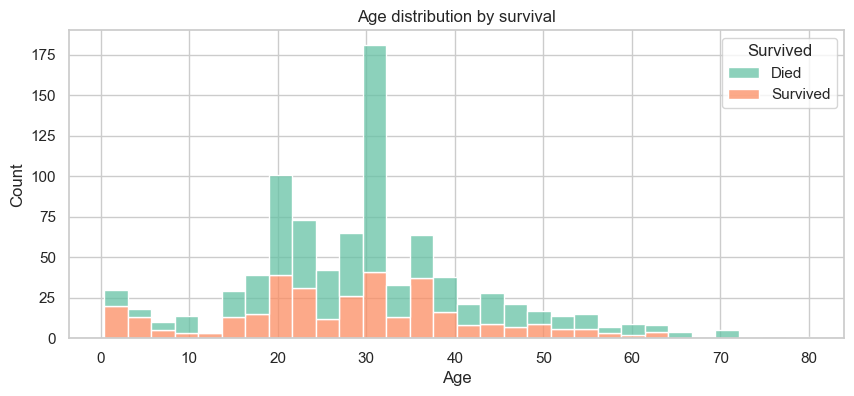

,mean,count
AgeGroup,,
Child,0.58,73
Teen,0.43,70
Young adult,0.35,530
Adult,0.40,196
Senior,0.23,22


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
outcome = data["Survived"].map({0: "Died", 1: "Survived"})
sns.histplot(data=data, x="Age", hue=outcome, bins=30, multiple="stack", ax=ax)
ax.set(title="Age distribution by survival")
plt.show()

data["AgeGroup"] = pd.cut(data["Age"], bins=[0, 12, 18, 35, 60, 80],
                          labels=["Child", "Teen", "Young adult", "Adult", "Senior"])
data.groupby("AgeGroup", observed=True)["Survived"].agg(["mean", "count"]).round(2)

Children (≤12) had the highest survival rate; seniors the lowest.

### Family size and port of embarkation

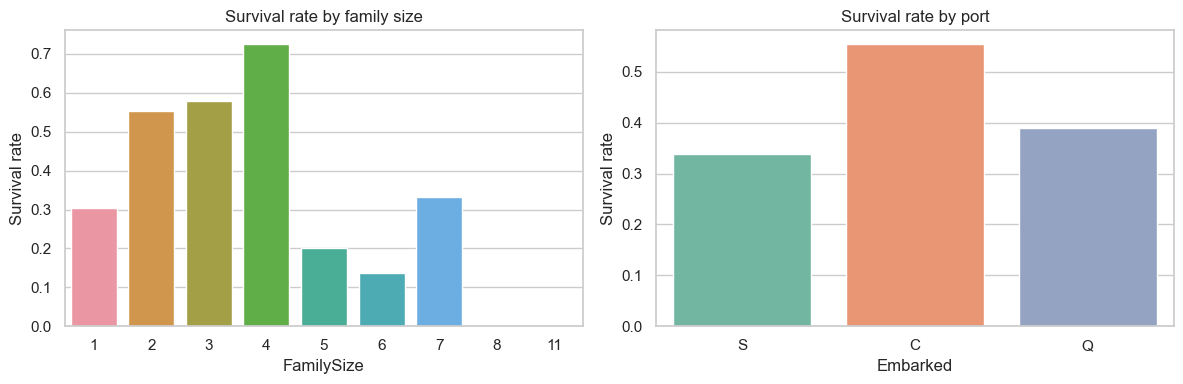

In [10]:
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=data, x="FamilySize", y="Survived", ax=axes[0], errorbar=None)
axes[0].set(title="Survival rate by family size", ylabel="Survival rate")
sns.barplot(data=data, x="Embarked", y="Survived", ax=axes[1], errorbar=None)
axes[1].set(title="Survival rate by port", ylabel="Survival rate")
plt.tight_layout()
plt.show()

Small families (2–4 people) did better than people travelling alone or in very large families.

### Correlation between numeric features

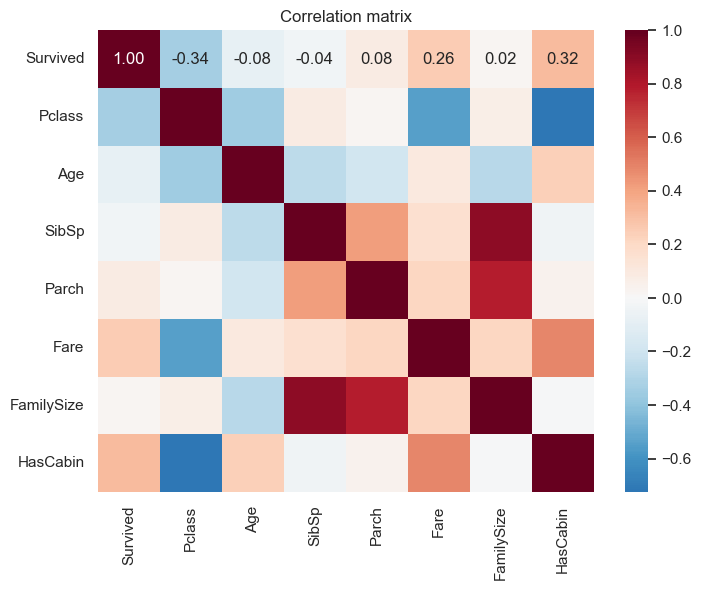

In [11]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "HasCabin"]
plt.figure(figsize=(8, 6))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation matrix")
plt.show()

## 4. Feature engineering

In [12]:
features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "HasCabin", "Embarked", "Title"]

X = pd.get_dummies(data[features], columns=["Sex", "Embarked", "Title"], drop_first=True)
y = data["Survived"]
X.head()

,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,7.2500,2,0,True,False,True,False,True,False,False
1,1,38.0,71.2833,2,1,False,False,False,False,False,True,False
2,3,26.0,7.9250,1,0,False,False,True,True,False,False,False
3,1,35.0,53.1000,2,1,False,False,True,False,False,True,False
4,3,35.0,8.0500,1,0,True,False,True,False,True,False,False


## 5. Modelling

We compare a simple baseline (predict that every woman survives) with two models, using 5‑fold cross‑validation.

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_acc = accuracy_score(y_test, (X_test["Sex_male"] == 0).astype(int))
print(f"Baseline (all women survive): {baseline_acc:.3f}")

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: CV accuracy {scores.mean():.3f} ± {scores.std():.3f}")

Baseline (all women survive): 0.777
Logistic Regression: CV accuracy 0.820 ± 0.019
Random Forest: CV accuracy 0.820 ± 0.024


Test accuracy: 0.810

              precision    recall  f1-score   support

        Died       0.82      0.89      0.85       110
    Survived       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



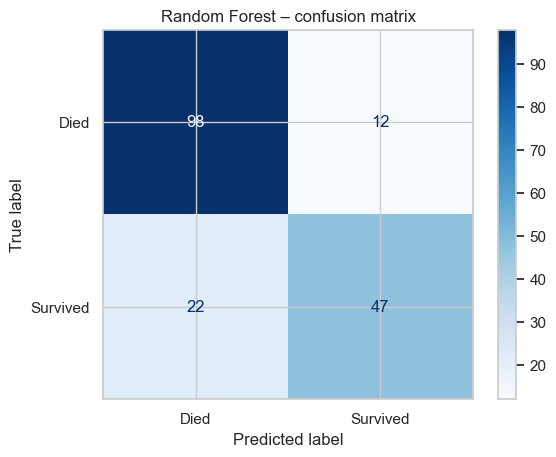

In [14]:
best = models["Random Forest"].fit(X_train, y_train)
pred = best.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["Died", "Survived"]))

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Died", "Survived"], cmap="Blues")
plt.title("Random Forest – confusion matrix")
plt.show()

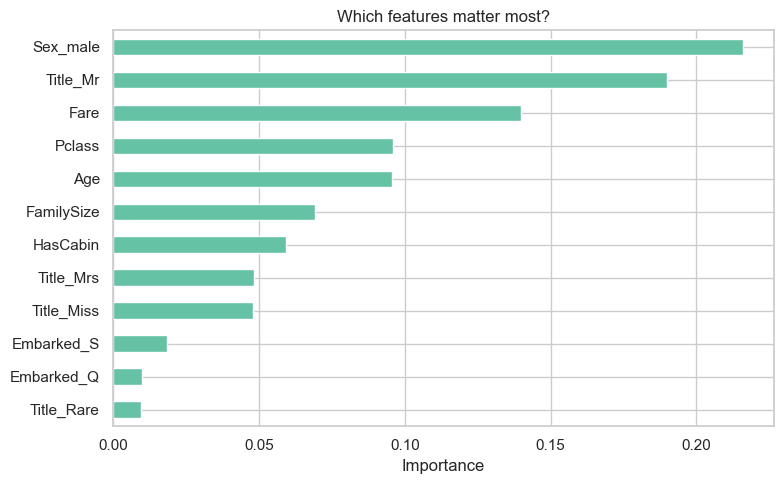

In [15]:
importance = pd.Series(best.feature_importances_, index=X.columns).sort_values()
importance.plot.barh(figsize=(8, 5), title="Which features matter most?")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=120)
plt.show()

## 6. Conclusions

- **Sex** was the strongest predictor of survival: women were roughly 4× more likely to survive than men.
- **Ticket class** mattered: 1st‑class passengers survived at about 63%, 3rd‑class at about 24%.
- **Children** and passengers in **small families** had better chances.
- A Random Forest model reaches about **82% cross‑validated accuracy** (81% on the held‑out test set), beating the simple “all women survive” baseline.

**Next steps** (section 7 below): tune hyper‑parameters, try gradient boosting, and submit predictions for `test.csv` to the Kaggle competition.

## 7. Improving the model and submitting to Kaggle

In this section we:
1. **Tune hyper‑parameters** of the Random Forest with a grid search.
2. **Try gradient boosting** – scikit‑learn's `GradientBoostingClassifier` and `XGBoost`.
3. **Compare** all models with the same 5‑fold cross‑validation.
4. **Predict `test.csv`** with the best model and create a Kaggle submission file.

### 7.1 Hyper‑parameter tuning: Random Forest

`GridSearchCV` tries every combination of the settings below and keeps the one with the best cross‑validated accuracy.
We use `StratifiedKFold` so every fold has the same share of survivors.

In [16]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [200, 500],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.5],
    },
    cv=cv, scoring="accuracy", n_jobs=-1,
)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print(f"Best CV accuracy: {rf_grid.best_score_:.3f}")

Best parameters: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}
Best CV accuracy: 0.836


### 7.2 Gradient boosting

Gradient boosting builds many small trees one after another, each one correcting the mistakes of the previous ones.
It has more settings than a Random Forest, so for XGBoost we use `RandomizedSearchCV`, which tests a random sample of 40 combinations instead of all of them.

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 1.0],
    },
    cv=cv, scoring="accuracy", n_jobs=-1,
)
gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print(f"Best CV accuracy: {gb_grid.best_score_:.3f}")

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best CV accuracy: 0.837


In [18]:
from xgboost import XGBClassifier

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions={
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    },
    n_iter=40, cv=cv, scoring="accuracy", n_jobs=-1, random_state=42,
)
xgb_search.fit(X_train, y_train)

print("Best parameters:", xgb_search.best_params_)
print(f"Best CV accuracy: {xgb_search.best_score_:.3f}")

Best parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV accuracy: 0.834


### 7.3 Model comparison

All models are scored with the same cross‑validation folds on the training split, and on the 20% hold‑out test split they have never seen.

In [19]:
candidates = {
    "Logistic Regression": models["Logistic Regression"],
    "Random Forest (default)": models["Random Forest"],
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (tuned)": gb_grid.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
}

rows = []
for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    rows.append({
        "model": name,
        "CV accuracy": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "hold-out accuracy": accuracy_score(y_test, model.predict(X_test)),
    })

results = pd.DataFrame(rows).set_index("model").sort_values("CV accuracy", ascending=False)
results.round(3)

,CV accuracy,CV std,hold-out accuracy
model,,,
Gradient Boosting (tuned),0.837,0.024,0.821
Random Forest (tuned),0.836,0.029,0.799
XGBoost (tuned),0.834,0.020,0.788
Logistic Regression,0.831,0.029,0.844
Random Forest (default),0.824,0.018,0.810


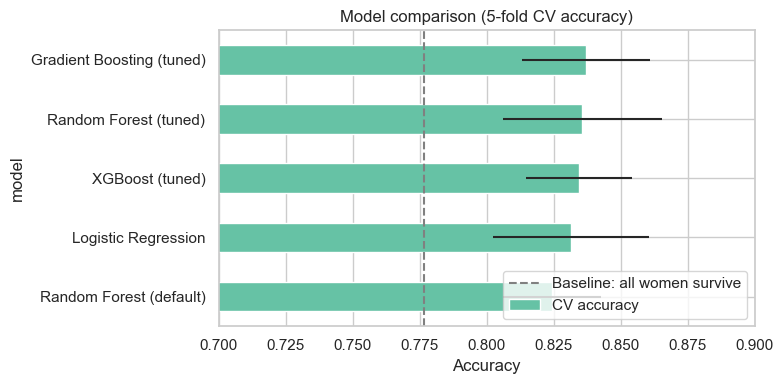

In [20]:
ax = results["CV accuracy"].sort_values().plot.barh(
    xerr=results["CV std"].reindex(results["CV accuracy"].sort_values().index),
    figsize=(8, 4), title="Model comparison (5-fold CV accuracy)",
)
ax.axvline(baseline_acc, color="grey", linestyle="--", label="Baseline: all women survive")
ax.set_xlim(0.7, 0.9)
ax.set_xlabel("Accuracy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=120)
plt.show()

The differences between the models are small (around 1–2 percentage points) and within the spread between folds.
On a dataset of only 891 passengers that is expected: the features we built matter more than the choice of algorithm.
We pick the model with the best **cross‑validated** accuracy, because it is a more reliable estimate than a single 179‑passenger hold‑out set.

In [21]:
best_name = results.index[0]
print(f"Best model: {best_name}")

Best model: Gradient Boosting (tuned)


### 7.4 Preparing `test.csv`

The test file must go through **exactly the same steps** as the training data.
Missing values are filled with statistics learned from the **training** data only (never from the test set), and the dummy columns are aligned with the training columns.
`test.csv` also has one missing `Fare`, which we fill with the median fare of that ticket class.

In [22]:
test_raw = pd.read_csv("../data/test.csv")
print(f"Test rows: {test_raw.shape[0]}")
print(test_raw.isna().sum()[lambda s: s > 0])

common_titles = data["Title"].unique()
title_age_median = data.groupby("Title")["Age"].median()
class_fare_median = df.groupby("Pclass")["Fare"].median()
embarked_mode = df["Embarked"].mode()[0]


def prepare_features(raw):
    """Apply the same cleaning and feature engineering as for the training data."""
    out = raw.copy()
    out["Title"] = out["Name"].str.extract(r",\s*([^\.]+)\.")
    out["Title"] = out["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    out.loc[~out["Title"].isin(common_titles), "Title"] = "Rare"
    out["Age"] = out["Age"].fillna(out["Title"].map(title_age_median))
    out["Fare"] = out["Fare"].fillna(out["Pclass"].map(class_fare_median))
    out["Embarked"] = out["Embarked"].fillna(embarked_mode)
    out["HasCabin"] = out["Cabin"].notna().astype(int)
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    encoded = pd.get_dummies(out[features], columns=["Sex", "Embarked", "Title"], drop_first=True)
    return encoded.reindex(columns=X.columns, fill_value=0)


X_submit = prepare_features(test_raw)
assert X_submit.isna().sum().sum() == 0
assert (prepare_features(df) == X).all().all()  # sanity check: same result as section 4 on the training data
X_submit.head()

Test rows: 418
Age       86
Fare       1
Cabin    327
dtype: int64


,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,34.5,7.8292,1,0,True,True,False,False,True,False,False
1,3,47.0,7.0000,2,0,False,False,True,False,False,True,False
2,2,62.0,9.6875,1,0,True,True,False,False,True,False,False
3,3,27.0,8.6625,1,0,True,False,True,False,True,False,False
4,3,22.0,12.2875,3,0,False,False,True,False,False,True,False


### 7.5 Final model and Kaggle submission

Now that the model is chosen, we retrain it on **all 891** training passengers (more data = a slightly better model) and predict the 418 test passengers.

In [23]:
from sklearn.base import clone
from pathlib import Path

final_model = clone(candidates[best_name]).fit(X, y)

submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": final_model.predict(X_submit).astype(int),
})

Path("../submissions").mkdir(exist_ok=True)
submission.to_csv("../submissions/submission.csv", index=False)

print(f"Saved {len(submission)} predictions to submissions/submission.csv")
print(f"Predicted survival rate: {submission['Survived'].mean():.1%} (training data: {y.mean():.1%})")
submission.head()

Saved 418 predictions to submissions/submission.csv
Predicted survival rate: 35.9% (training data: 38.4%)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


**How to submit:** go to the [Titanic competition page](https://www.kaggle.com/competitions/titanic/submissions), click **Submit Prediction**, upload `submissions/submission.csv`, and Kaggle shows your public leaderboard score.

Kaggle scores the submission on passengers our model has never seen, so expect the leaderboard score to be a few points below the cross‑validated accuracy. Around 0.77–0.79 is typical for this kind of model.

| Model | Kaggle public score |
|---|---|
| Gradient Boosting (tuned) | **0.77511** |

The leaderboard score (77.5%) is about 6 points below the cross‑validated accuracy (83.7%), which suggests the model still overfits the small training set slightly. The ideas in section 8 (ticket/family groups, ensembles) are the natural next things to try.

## 8. Final conclusions

- **Feature engineering beat algorithm choice.** Title, sex, class and family size carry most of the signal; tuning and gradient boosting changed accuracy by only 1–2 percentage points.
- **Tuning helps a little.** Limiting tree depth and leaf size stops the models from memorising the small training set.
- **The evaluation was honest.** Test data was prepared using only statistics from the training data, and models were compared with the same cross‑validation folds.

**Ideas to go further** (tried in section 9 below): group passengers who share a ticket or surname (families often survived or died together), combine several models in an ensemble, or add features from the `Ticket` and `Cabin` deck letter.

## 9. Going further: group features and an ensemble

Our Kaggle score (0.775) was about 6 points below the cross‑validated accuracy, so there is room to improve.
In this section we:
1. Add **new features**: the cabin **deck**, the **ticket group size** and **fare per person**.
2. Add a **group survival** feature: passengers who travelled together (same ticket or same family) often survived or died together.
3. **Combine several models** in a voting ensemble.
4. Create a second Kaggle submission.

### 9.1 New features from `Cabin`, `Ticket` and `Name`

- **Deck**: the first letter of the cabin (A = top deck … F = lower decks). `U` = unknown. The rare decks G and T are merged into `U`.
- **TicketGroupSize**: how many passengers share the same ticket number. Friends, servants and nannies often shared a ticket without being family, so this captures groups that `FamilySize` misses.
- **FarePerPerson**: the `Fare` is the price of the whole ticket, so we divide it by the group size.

We count tickets across **train and test together**. This only uses passenger information, never the `Survived` labels, so it is allowed: a group may have members in both files.

In [24]:
full = pd.concat([df, test_raw], ignore_index=True)
n_train = len(df)

# Same cleaning as before (statistics from training data only)
full["Title"] = full["Name"].str.extract(r",\s*([^\.]+)\.")
full["Title"] = full["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
full.loc[~full["Title"].isin(common_titles), "Title"] = "Rare"
full["Age"] = full["Age"].fillna(full["Title"].map(title_age_median))
full["Fare"] = full["Fare"].fillna(full["Pclass"].map(class_fare_median))
full["Embarked"] = full["Embarked"].fillna(embarked_mode)
full["HasCabin"] = full["Cabin"].notna().astype(int)
full["FamilySize"] = full["SibSp"] + full["Parch"] + 1

# New features
full["Deck"] = full["Cabin"].str[0].fillna("U").replace({"G": "U", "T": "U"})
full["TicketGroupSize"] = full.groupby("Ticket")["Ticket"].transform("size")
full["FarePerPerson"] = full["Fare"] / full["TicketGroupSize"]

full[["Name", "Cabin", "Deck", "Ticket", "TicketGroupSize", "Fare", "FarePerPerson"]].head()

,Name,Cabin,Deck,Ticket,TicketGroupSize,Fare,FarePerPerson
0,"Braund, Mr. Owen Harris",NaN,U,A/5 21171,1,7.2500,7.25000
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",C85,C,PC 17599,2,71.2833,35.64165
2,"Heikkinen, Miss. Laina",NaN,U,STON/O2. 3101282,1,7.9250,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",C123,C,113803,2,53.1000,26.55000
4,"Allen, Mr. William Henry",NaN,U,373450,1,8.0500,8.05000


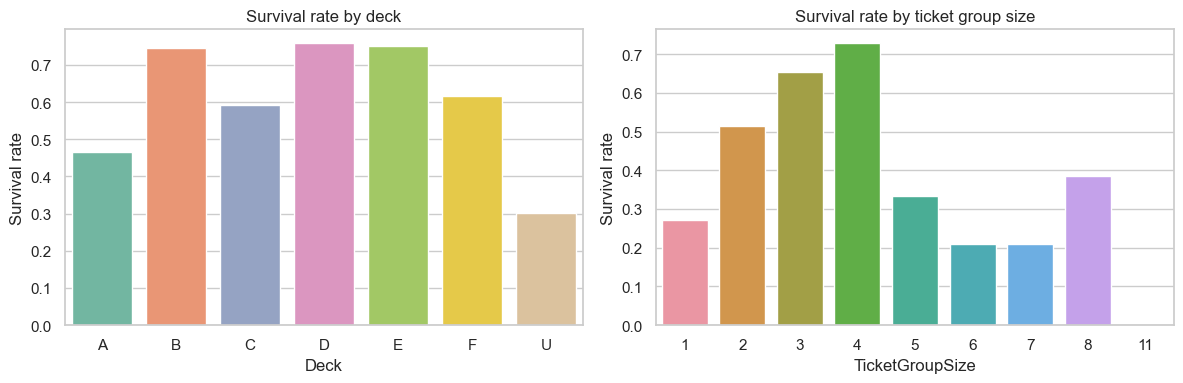

In [25]:
train_full = full.iloc[:n_train]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=train_full, x="Deck", y="Survived", order=sorted(train_full["Deck"].unique()),
            ax=axes[0], errorbar=None)
axes[0].set(title="Survival rate by deck", ylabel="Survival rate")
sns.barplot(data=train_full, x="TicketGroupSize", y="Survived", ax=axes[1], errorbar=None)
axes[1].set(title="Survival rate by ticket group size", ylabel="Survival rate")
plt.tight_layout()
plt.show()

Passengers with a known deck (mostly 1st class) survived far more often than those with an unknown cabin (`U`).
The ticket group pattern looks like family size: groups of 2–4 did best.

### 9.2 Group survival

If we know what happened to the **other members** of a passenger's group, that is a strong hint about what happened to them.
For example, in a family where the mother and children all died, a remaining child very likely died too.

We define two kinds of group:
- **Family**: same surname, same class and same fare (to avoid joining unrelated people with common surnames like "Smith").
- **Ticket**: same ticket number.

For every passenger, `GroupSurvival` is the survival rate of the **other** group members whose outcome we know (from `train.csv`).
A passenger's own label is **never** used for their own feature.
If there is no known group member, we use 0.5 ("no information") and set `GroupKnown` = 0.

In [26]:
full["Surname"] = full["Name"].str.split(",").str[0]
full["FamilyGroup"] = full["Surname"] + "_" + full["Pclass"].astype(str) + "_" + full["Fare"].round(1).astype(str)


def others_survival_rate(group_col):
    """Survival rate of the *other* known members of each passenger's group (NaN if none)."""
    known = full["Survived"]                      # NaN for test passengers
    group_sum = full.groupby(group_col)["Survived"].transform("sum")
    group_count = full.groupby(group_col)["Survived"].transform("count")
    others_sum = group_sum - known.fillna(0)      # remove the passenger's own label
    others_count = group_count - known.notna()
    return (others_sum / others_count).where(others_count > 0)


family_rate = others_survival_rate("FamilyGroup")
ticket_rate = others_survival_rate("Ticket")

full["GroupSurvival"] = family_rate.fillna(ticket_rate).fillna(0.5)
full["GroupKnown"] = (family_rate.notna() | ticket_rate.notna()).astype(int)

print(f"Training passengers with a known group member: {full['GroupKnown'][:n_train].mean():.0%}")
print(f"Test passengers with a known group member:     {full['GroupKnown'][n_train:].mean():.0%}")

Training passengers with a known group member: 43%
Test passengers with a known group member:     42%


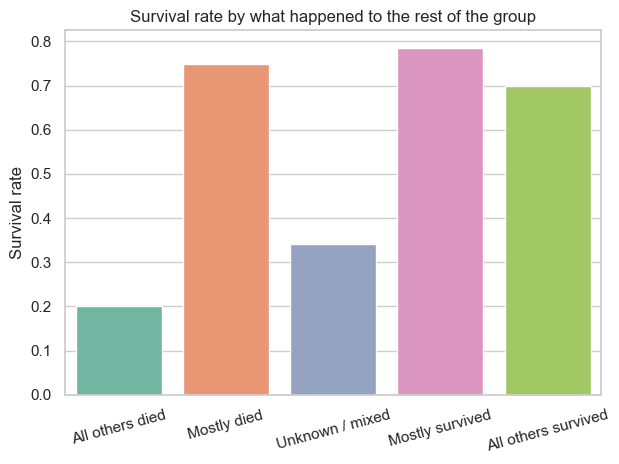

In [27]:
train_full = full.iloc[:n_train]
group_view = train_full.assign(
    Group=pd.cut(train_full["GroupSurvival"], bins=[-0.01, 0.0, 0.49, 0.5, 0.99, 1.0],
                 labels=["All others died", "Mostly died", "Unknown / mixed", "Mostly survived", "All others survived"]).astype(str)
)
ax = sns.barplot(data=group_view, x="Group", y="Survived", errorbar=None,
                 order=["All others died", "Mostly died", "Unknown / mixed", "Mostly survived", "All others survived"])
ax.set(title="Survival rate by what happened to the rest of the group", xlabel="", ylabel="Survival rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../images/group_survival.png", dpi=120)
plt.show()

This is a very strong signal: when all other known group members died, very few passengers survived, and when all others survived, most did.

### 9.3 Do the new features help?

We compare three feature sets with the tuned Gradient Boosting model, using the same cross‑validation folds as section 7.
This time we evaluate on **all 891** training passengers, because the final model is trained on all of them.

> **Note:** `GroupSurvival` for a passenger is built from the labels of *other* passengers. Inside cross‑validation some of those other passengers sit in the validation fold, so the CV score here is a little optimistic. The Kaggle score is the real test.

In [28]:
cat_cols = ["Sex", "Embarked", "Title", "Deck"]
feature_sets = {
    "Original features": features,
    "+ deck & ticket": features + ["Deck", "TicketGroupSize", "FarePerPerson"],
    "+ deck, ticket & group survival": features + ["Deck", "TicketGroupSize", "FarePerPerson", "GroupSurvival", "GroupKnown"],
}


def encode(cols):
    encoded = pd.get_dummies(full[cols], columns=[c for c in cat_cols if c in cols], drop_first=True)
    return encoded.iloc[:n_train], encoded.iloc[n_train:]


rows = []
for name, cols in feature_sets.items():
    X_tr, _ = encode(cols)
    scores = cross_val_score(gb_grid.best_estimator_, X_tr, y, cv=cv, scoring="accuracy")
    rows.append({"feature set": name, "CV accuracy": scores.mean(), "CV std": scores.std()})

pd.DataFrame(rows).set_index("feature set").round(3)

,CV accuracy,CV std
feature set,,
Original features,0.845,0.015
+ deck & ticket,0.848,0.015
"+ deck, ticket & group survival",0.855,0.009


The deck and ticket features give a small gain; the group survival feature gives the biggest jump.

### 9.4 Voting ensemble

Different models make different mistakes. A **soft‑voting ensemble** averages the predicted survival probabilities of several models, which often makes the predictions more stable.
We combine the four tuned models from section 7.

In [29]:
from sklearn.ensemble import VotingClassifier

X_new, X_submit_new = encode(feature_sets["+ deck, ticket & group survival"])

ensemble = VotingClassifier(
    estimators=[
        ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
        ("rf", clone(rf_grid.best_estimator_)),
        ("gb", clone(gb_grid.best_estimator_)),
        ("xgb", clone(xgb_search.best_estimator_)),
    ],
    voting="soft",
)

new_models = {
    "Logistic Regression": ensemble.named_estimators["lr"],
    "Random Forest (tuned)": ensemble.named_estimators["rf"],
    "Gradient Boosting (tuned)": ensemble.named_estimators["gb"],
    "XGBoost (tuned)": ensemble.named_estimators["xgb"],
    "Voting ensemble": ensemble,
}

rows = []
for name, model in new_models.items():
    scores = cross_val_score(model, X_new, y, cv=cv, scoring="accuracy")
    rows.append({"model": name, "CV accuracy": scores.mean(), "CV std": scores.std()})

results_new = pd.DataFrame(rows).set_index("model").sort_values("CV accuracy", ascending=False)
results_new.round(3)

,CV accuracy,CV std
model,,
Gradient Boosting (tuned),0.855,0.009
Voting ensemble,0.852,0.012
XGBoost (tuned),0.851,0.012
Random Forest (tuned),0.845,0.009
Logistic Regression,0.837,0.017


With the new features, every model improves compared with section 7. The ensemble scores almost the same as the best single model (Gradient Boosting); the difference is far smaller than the spread between folds, so on this data the two are effectively tied.
We submit the **ensemble** for the second submission because our first submission already used Gradient Boosting alone. This way Kaggle tells us whether combining models helps on unseen passengers.

### 9.5 Second Kaggle submission

In [30]:
final_ensemble = clone(ensemble).fit(X_new, y)

submission_v2 = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": final_ensemble.predict(X_submit_new).astype(int),
})
submission_v2.to_csv("../submissions/submission_v2_groups_ensemble.csv", index=False)

changed = (submission_v2["Survived"] != submission["Survived"]).sum()
print(f"Saved {len(submission_v2)} predictions to submissions/submission_v2_groups_ensemble.csv")
print(f"Predicted survival rate: {submission_v2['Survived'].mean():.1%}")
print(f"Predictions changed compared with the first submission: {changed} of {len(submission_v2)}")

Saved 418 predictions to submissions/submission_v2_groups_ensemble.csv
Predicted survival rate: 36.1%
Predictions changed compared with the first submission: 37 of 418


Upload `submissions/submission_v2_groups_ensemble.csv` on the [competition page](https://www.kaggle.com/competitions/titanic/submissions) the same way as before.

| Submission | Model | Kaggle public score |
|---|---|---|
| v1 | Gradient Boosting (tuned), original features | 0.77511 |
| v2 | Voting ensemble, + deck, ticket & group survival | _fill in after submitting_ |

## 10. Conclusions

- **What happened to your travel group** was one of the strongest predictors of survival, after sex and class. Families and ticket groups tended to survive or die together.
- **Deck, ticket group size and fare per person** added a little extra signal.
- **The ensemble** performed about as well as the best single model in cross‑validation; on a dataset this small, combining models gives little extra.
- **Lesson learned:** on small tabular datasets, understanding the data and building good features matters more than choosing a fancier algorithm.